In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split # Split the data into training and testing sets. Typically, an 80-20 or 70-30 split is used.
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer # Convert the text into numerical features. You can use methods like CountVectorizer or TfidfVectorizer.
# Download required resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab') # Download the 'punkt_tab' data package

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
traindata = "/content/training.csv"
validdata = "/content/validation.csv"
testdata = "/content/test.csv"

# traindata = "/content/sample_data/training.csv"
# validdata = "/content/sample_data/validation.csv"
# testdata = "/content/sample_data/test.csv"
train = pd.read_csv(traindata)
valid = pd.read_csv(validdata)
test = pd.read_csv(testdata)

dataset = pd.concat([train, valid, test], ignore_index=True)

dataset.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
dataset.shape[0]

20000

In [ ]:
dataset['label'].value_counts()

,count
label,
1,6761
0,5797
3,2709
4,2373
2,1641
5,719


In [ ]:
# Check for missing values
dataset.isnull().sum()

,0
text,0
label,0


In [ ]:
dataset

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
19995,i just keep feeling like someone is being unki...,3
19996,im feeling a little cranky negative after this...,3
19997,i feel that i am useful to my people and that ...,1
19998,im feeling more comfortable with derby i feel ...,1


In [ ]:
labels = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

dataset['emotion'] = dataset['label'].map(labels)

In [ ]:
dataset['emotion'].value_counts()

,count
emotion,
joy,6761
sadness,5797
anger,2709
fear,2373
love,1641
surprise,719


In [ ]:
dataset

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
...,...,...,...
19995,i just keep feeling like someone is being unki...,3,anger
19996,im feeling a little cranky negative after this...,3,anger
19997,i feel that i am useful to my people and that ...,1,joy
19998,im feeling more comfortable with derby i feel ...,1,joy


In [ ]:
# Handle duplicates: If there are any duplicate rows, you might want to remove them.
dataset.drop_duplicates(inplace=True)

In [ ]:
dataset

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
...,...,...,...
19995,i just keep feeling like someone is being unki...,3,anger
19996,im feeling a little cranky negative after this...,3,anger
19997,i feel that i am useful to my people and that ...,1,joy
19998,im feeling more comfortable with derby i feel ...,1,joy


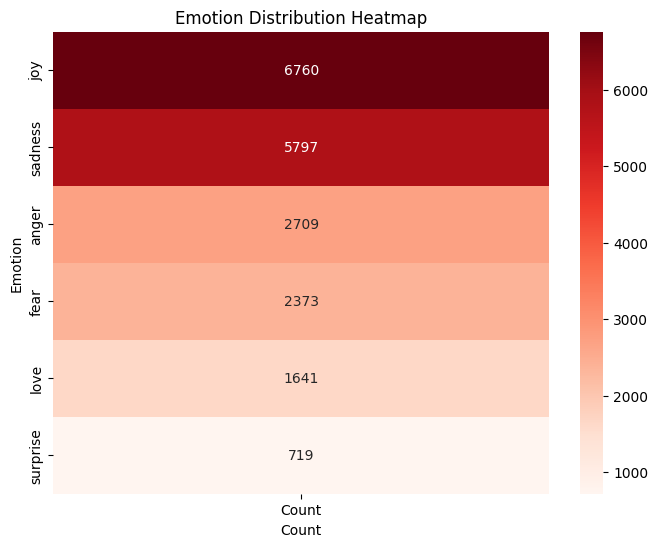

In [ ]:
# Map the numerical labels to emotion names
dataset['emotion'] = dataset['label'].map(labels)

# Count the frequency of each emotion
emotion_counts = dataset['emotion'].value_counts()

# Create a DataFrame for the heatmap
heatmap_data = pd.DataFrame({'Emotion': emotion_counts.index, 'Count': emotion_counts.values}).set_index('Emotion')

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', fmt='d')
plt.title('Emotion Distribution Heatmap')
plt.ylabel('Emotion')
plt.xlabel('Count')
plt.show()

<ipython-input-145-4ab2e5952b2f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=dataset, palette='viridis')
<ipython-input-145-4ab2e5952b2f>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='emotion', data=dataset, palette='viridis')


Text(0.5, 1.0, 'Label Distribution as Emotion')

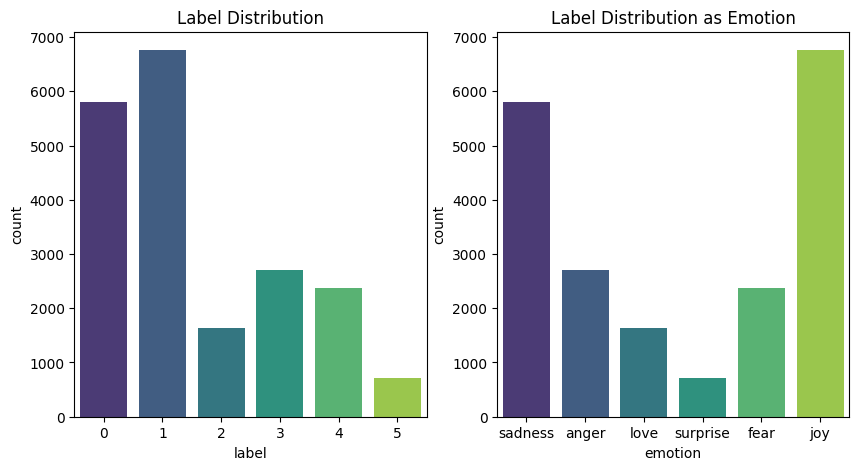

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1) #Plot 1
sns.countplot(x='label', data=dataset, palette='viridis')
plt.title('Label Distribution')

plt.subplot(1, 2, 2) #Plot 2
sns.countplot(x='emotion', data=dataset, palette='viridis')
plt.title('Label Distribution as Emotion')

# **#Feature Scaling or Upscaling**

In [ ]:
# Oversampling Minority Classes

from sklearn.utils import resample
import pandas as pd

# Separate majority and minority classes
majority_class = dataset[dataset['label'].isin([0, 1])]   # Replace with majority class
minority_classes = dataset[dataset['label'].isin([2, 3, 4, 5])]   # Replace with minority classes

# Oversample minority classes
upsampled_minority = resample(minority_classes,
                              replace=True,   # Sample with replacement
                              n_samples=len(majority_class),   # Match majority class size
                              random_state=42)

# Combine the majority and upsampled minority classes
scaled_train = pd.concat([majority_class, upsampled_minority])

# Shuffle the dataset
# scaled_train = scaled_train.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
print(f"Original class distribution: \n{dataset['emotion'].value_counts()}")
print(f"Resampled class distribution: \n{scaled_train['emotion'].value_counts()}")

Original class distribution: 
emotion
joy         6760
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719
Name: count, dtype: int64
Resampled class distribution: 
emotion
joy         6760
sadness     5797
anger       4612
fear        3991
love        2723
surprise    1231
Name: count, dtype: int64


In [ ]:
# Text Augmentation Techniques

In [ ]:
scaled_train.reset_index(drop=True)

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,ive been feeling a little burdened lately wasn...,0,sadness
3,i have been with petronas for years i feel tha...,1,joy
4,i feel like i have to make the suffering i m s...,0,sadness
...,...,...,...
25109,when junior doctors returned to work after bun...,3,anger
25110,i seem to feel some fondness for this curious ...,5,surprise
25111,someone acting stupid in public,3,anger
25112,i worked as a computer tech this ability to hy...,3,anger


<ipython-input-150-9add08db0181>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='emotion', data=scaled_train, palette='viridis')


Text(0.5, 1.0, 'NEW Label Distribution as Emotion')

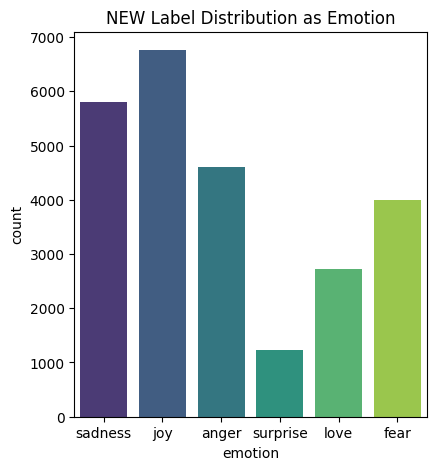

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='emotion', data=scaled_train, palette='viridis')
plt.title('NEW Label Distribution as Emotion')

In [ ]:
scaled_train

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
5,ive been feeling a little burdened lately wasn...,0,sadness
8,i have been with petronas for years i feel tha...,1,joy
10,i feel like i have to make the suffering i m s...,0,sadness
...,...,...,...
14457,when junior doctors returned to work after bun...,3,anger
16504,i seem to feel some fondness for this curious ...,5,surprise
17124,someone acting stupid in public,3,anger
3483,i worked as a computer tech this ability to hy...,3,anger


# **#Feature Selection (Lemmatizing & Tokenization)**

In [ ]:
#VERY IMPORTANT ==============================
#VERY IMPORTANT ==============================
#VERY IMPORTANT ==============================





train = scaled_train






#VERY IMPORTANT ==============================
#VERY IMPORTANT ==============================
#VERY IMPORTANT ==============================

In [ ]:
# Initialize lemmatizer and stop words
# Lem: reduces word to their base form
# re.sub: removes anything thats not a letter
# token: breaks down to individual words

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = nltk.word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Join words back into a string
    return ' '.join(tokens)

In [ ]:
# Apply text preprocessing

train['processed_text'] = train['text'].apply(preprocess_text)
train['tokens'] = train['processed_text'].apply(word_tokenize)
valid['processed_text'] = valid['text'].apply(preprocess_text)
valid['tokens'] = valid['processed_text'].apply(word_tokenize)
test['processed_text'] = test['text'].apply(preprocess_text)
test['tokens'] = test['processed_text'].apply(word_tokenize)

In [ ]:
train

,text,label,emotion,processed_text,tokens
0,i didnt feel humiliated,0,sadness,didnt feel humiliated,"[didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,0,sadness,go feeling hopeless damned hopeful around some...,"[go, feeling, hopeless, damned, hopeful, aroun..."
5,ive been feeling a little burdened lately wasn...,0,sadness,ive feeling little burdened lately wasnt sure,"[ive, feeling, little, burdened, lately, wasnt..."
8,i have been with petronas for years i feel tha...,1,joy,petronas year feel petronas performed well mad...,"[petronas, year, feel, petronas, performed, we..."
10,i feel like i have to make the suffering i m s...,0,sadness,feel like make suffering seeing mean something,"[feel, like, make, suffering, seeing, mean, so..."
...,...,...,...,...,...
14457,when junior doctors returned to work after bun...,3,anger,junior doctor returned work bunking,"[junior, doctor, returned, work, bunking]"
16504,i seem to feel some fondness for this curious ...,5,surprise,seem feel fondness curious old man,"[seem, feel, fondness, curious, old, man]"
17124,someone acting stupid in public,3,anger,someone acting stupid public,"[someone, acting, stupid, public]"
3483,i worked as a computer tech this ability to hy...,3,anger,worked computer tech ability hyper focus one i...,"[worked, computer, tech, ability, hyper, focus..."


In [ ]:
train['label'].value_counts()

,count
label,
1,6760
0,5797
3,4612
4,3991
2,2723
5,1231


In [ ]:
# Split the data
#X_train, X_test, y_train, y_test = train_test_split(train['text'], train['label'], test_size=0.25, random_state=42)
X_temp, X_test, y_temp, y_test = train_test_split(train['processed_text'], train['label'], test_size=0.25, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.05, random_state=42)
# Verify split sizes
print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_valid)}")
print(f"Test size: {len(X_test)}")

Train size: 17893
Validation size: 942
Test size: 6279


In [ ]:
train

,text,label,emotion,processed_text,tokens
0,i didnt feel humiliated,0,sadness,didnt feel humiliated,"[didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,0,sadness,go feeling hopeless damned hopeful around some...,"[go, feeling, hopeless, damned, hopeful, aroun..."
5,ive been feeling a little burdened lately wasn...,0,sadness,ive feeling little burdened lately wasnt sure,"[ive, feeling, little, burdened, lately, wasnt..."
8,i have been with petronas for years i feel tha...,1,joy,petronas year feel petronas performed well mad...,"[petronas, year, feel, petronas, performed, we..."
10,i feel like i have to make the suffering i m s...,0,sadness,feel like make suffering seeing mean something,"[feel, like, make, suffering, seeing, mean, so..."
...,...,...,...,...,...
14457,when junior doctors returned to work after bun...,3,anger,junior doctor returned work bunking,"[junior, doctor, returned, work, bunking]"
16504,i seem to feel some fondness for this curious ...,5,surprise,seem feel fondness curious old man,"[seem, feel, fondness, curious, old, man]"
17124,someone acting stupid in public,3,anger,someone acting stupid public,"[someone, acting, stupid, public]"
3483,i worked as a computer tech this ability to hy...,3,anger,worked computer tech ability hyper focus one i...,"[worked, computer, tech, ability, hyper, focus..."


# **#Feature Engineering or Feature Extraction**

In [ ]:
# Initialize the vectorizer
# Vec: text to numerical values, marks unique values/words
# fit: learns the vocabulary (the set of unique words)

vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data (no fitting on test data)
X_test_tfidf = vectorizer.transform(X_test)

X_valid_tfidf = vectorizer.transform(X_valid)

# Check the shape of the transformed data
print(X_train_tfidf.shape)

(17893, 5000)


In [ ]:
token_matrix = vectorizer.fit_transform(train['processed_text'])
token_matrix.shape

(25114, 5000)

# **Word Cloud**

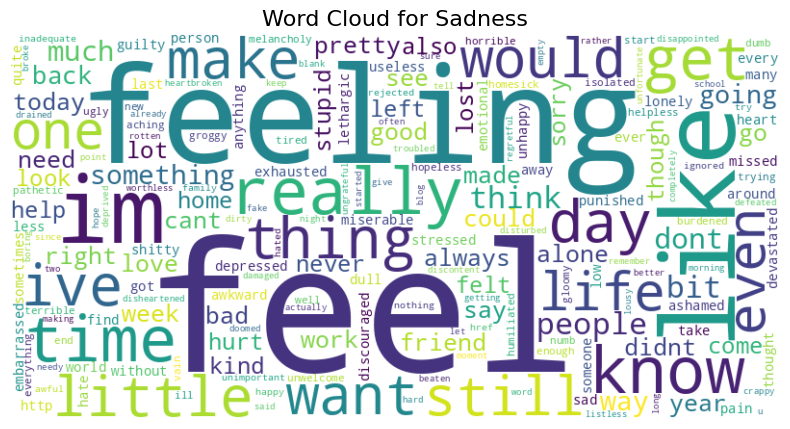

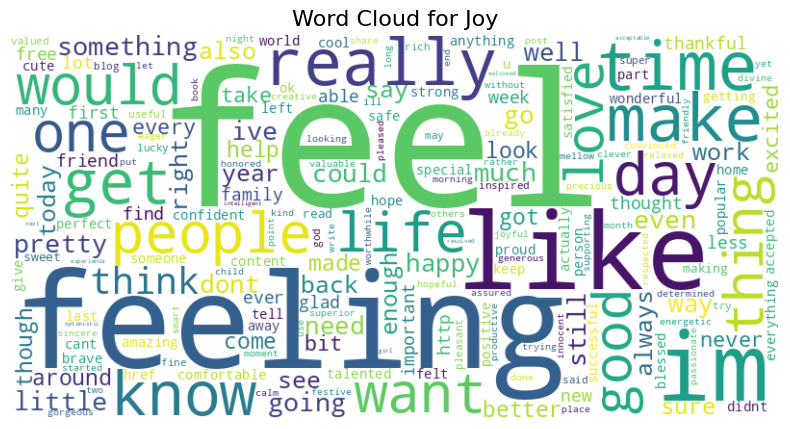

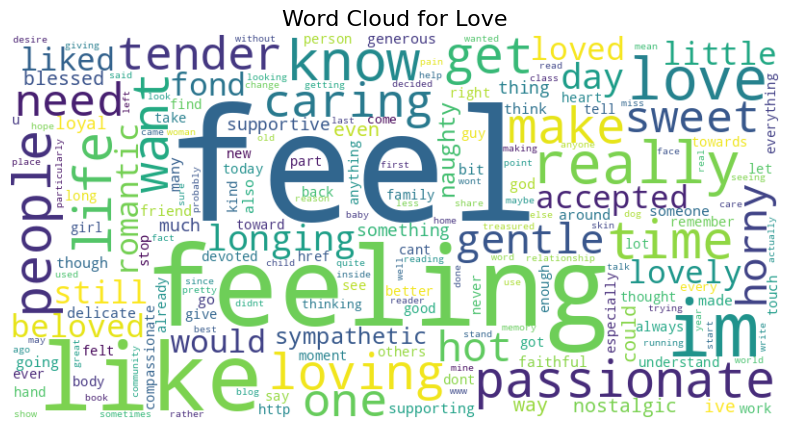

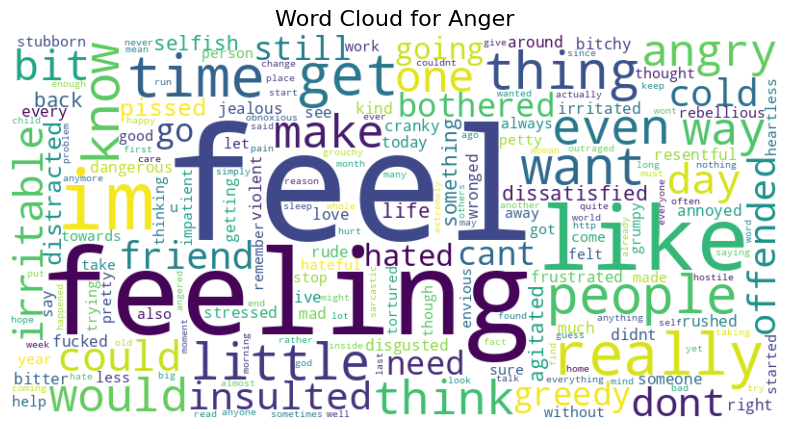

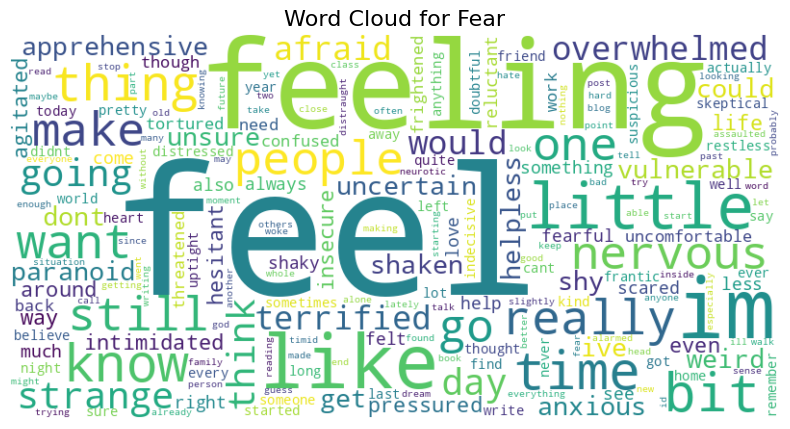

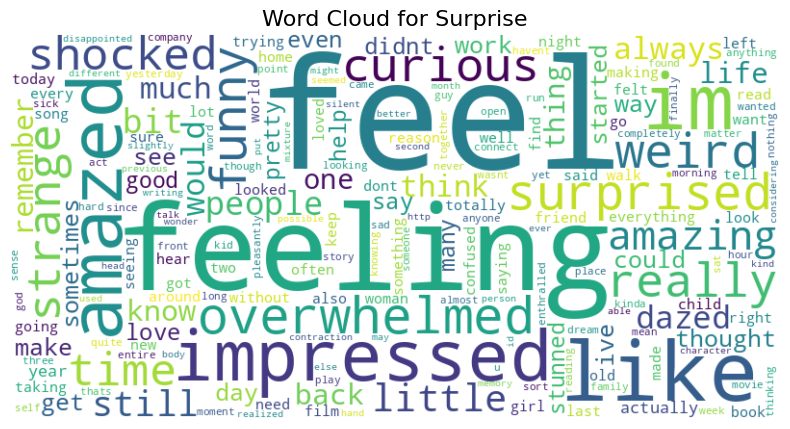

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

count_vectorizer = CountVectorizer(analyzer=lambda x: x)  # Custom analyzer to pass pre-tokenized data
tokenized_texts = train['tokens']
bow_matrix = count_vectorizer.fit_transform(tokenized_texts).toarray()
word_features = count_vectorizer.get_feature_names_out()

for label, emotion in labels.items():
    # Filter tokens for the current label
    label_tokens = train[train['label'] == label]['tokens']

    # Flatten the list of tokens into a single list
    all_words = [word for tokens in label_tokens for word in tokens]  # Directly iterate over lists

    # Count word frequencies
    word_freq = Counter(all_words)

    # Generate the word cloud
    wordcloud = WordCloud(
        width=800, height=400, background_color='white', colormap='viridis'
    ).generate_from_frequencies(word_freq)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {emotion.capitalize()}", fontsize=16)
    plt.show()

# **Logistics Regression**

Logistic Regression Validation Accuracy 0.9012738853503185
Logistic Regression Test Accuracy 0.9186176142697882
Logistic Regression Validation Precision 0.9026635335199413
Logistic Regression Test Precision 0.9188517801313314
Logistic Regression Validation Recall 0.9012738853503185
Logistic Regression Test Recall 0.9186176142697882
{'0': {'precision': 0.9285714285714286, 'recall': 0.8863636363636364, 'f1-score': 0.9069767441860465, 'support': 220.0}, '1': {'precision': 0.8685258964143426, 'recall': 0.923728813559322, 'f1-score': 0.8952772073921971, 'support': 236.0}, '2': {'precision': 0.8811881188118812, 'recall': 0.8811881188118812, 'f1-score': 0.8811881188118812, 'support': 101.0}, '3': {'precision': 0.9044943820224719, 'recall': 0.92, 'f1-score': 0.9121813031161473, 'support': 175.0}, '4': {'precision': 0.9107142857142857, 'recall': 0.9107142857142857, 'f1-score': 0.9107142857142857, 'support': 168.0}, '5': {'precision': 0.9705882352941176, 'recall': 0.7857142857142857, 'f1-score':

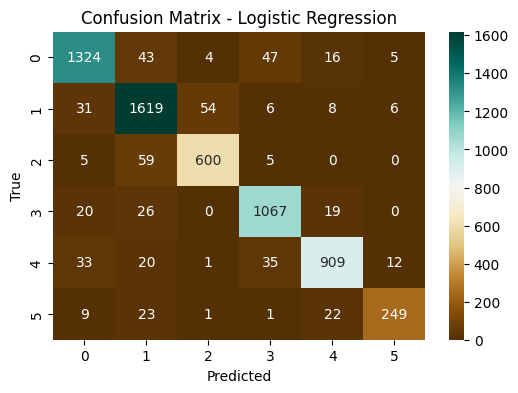

In [ ]:
#LogicRegression Plugin

logistic_model = LogisticRegression()
logistic_model.fit(X_train_tfidf, y_train)

y_valid_pred = logistic_model.predict(X_valid_tfidf)
y_test_pred = logistic_model.predict(X_test_tfidf)

#Calculating Classification Matrix
valid_acc_log = accuracy_score(y_valid, y_valid_pred)
test_acc_log = accuracy_score(y_test, y_test_pred)

valid_prec_log = precision_score(y_valid, y_valid_pred, average='weighted')
test_prec_log = precision_score(y_test, y_test_pred, average='weighted')

valid_recall_log = recall_score(y_valid, y_valid_pred, average='weighted')
test_recall_log = recall_score(y_test, y_test_pred, average='weighted')

print(f"Logistic Regression Validation Accuracy {valid_acc_log}")
print(f"Logistic Regression Test Accuracy {test_acc_log}")
print(f"Logistic Regression Validation Precision {valid_prec_log}")
print(f"Logistic Regression Test Precision {test_prec_log}")
print(f"Logistic Regression Validation Recall {valid_recall_log}")
print(f"Logistic Regression Test Recall {test_recall_log}")

validation_classification_report_log = classification_report(y_valid, y_valid_pred, output_dict=True)
test_classification_report_log = classification_report(y_test, y_test_pred, output_dict=True)
print(f"{validation_classification_report_log}")
print(f"{test_classification_report_log}")

# Confusion Matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="BrBG")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# df_report = pd.DataFrame(validation_classification_report_log)
# df_report = df_report.transpose()
# # Drop rows like "accuracy", "macro avg", and "weighted avg" for class-wise metrics
# df_report = df_report.iloc[:-3, :]

# # Precision and recall bar charts
# plt.figure(figsize=(10, 6))

# # Plot precision
# plt.subplot(1, 2, 1)
# sns.barplot(x=df_report.index, y=df_report['precision'], palette='Blues')
# plt.title('Precision by Class')
# plt.xlabel('Class')
# plt.ylabel('Precision')
# plt.xticks(rotation=45)

# # Plot recall
# plt.subplot(1, 2, 2)
# sns.barplot(x=df_report.index, y=df_report['recall'], palette='Greens')
# plt.title('Recall by Class')
# plt.xlabel('Class')
# plt.ylabel('Recall')
# plt.xticks(rotation=45)

# # Adjust layout
# plt.tight_layout()
# plt.show()

# **Decision Tree**

Decision Tree Validation Accuracy 0.9150743099787686
Decision Tree Test Accuracy 0.917184265010352
Decision Tree Validation Precision 0.9159049791738281
Decision Tree Test Precision 0.9182297172427706
Decision Tree Validation Recall 0.9150743099787686
Decision Tree Test Recall 0.917184265010352
{'0': {'precision': 0.9567307692307693, 'recall': 0.9045454545454545, 'f1-score': 0.9299065420560748, 'support': 220.0}, '1': {'precision': 0.9162995594713657, 'recall': 0.8813559322033898, 'f1-score': 0.8984881209503239, 'support': 236.0}, '2': {'precision': 0.8773584905660378, 'recall': 0.9207920792079208, 'f1-score': 0.8985507246376812, 'support': 101.0}, '3': {'precision': 0.9175824175824175, 'recall': 0.9542857142857143, 'f1-score': 0.9355742296918768, 'support': 175.0}, '4': {'precision': 0.898876404494382, 'recall': 0.9523809523809523, 'f1-score': 0.9248554913294798, 'support': 168.0}, '5': {'precision': 0.8536585365853658, 'recall': 0.8333333333333334, 'f1-score': 0.8433734939759037, 'su

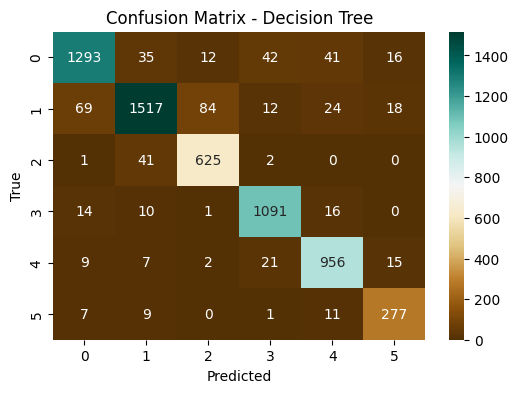

In [ ]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train_tfidf, y_train)

y_valid_pred_tree = np.round(tree_model.predict(X_valid_tfidf)).astype(int)
y_test_pred_tree = np.round(tree_model.predict(X_test_tfidf)).astype(int)

#Calculating Classification Matrix
valid_acc_tree = accuracy_score(y_valid, y_valid_pred_tree)
test_acc_tree = accuracy_score(y_test, y_test_pred_tree)

valid_prec_tree = precision_score(y_valid, y_valid_pred_tree, average='weighted')
test_prec_tree = precision_score(y_test, y_test_pred_tree, average='weighted')

valid_recall_tree = recall_score(y_valid, y_valid_pred_tree, average='weighted')
test_recall_tree = recall_score(y_test, y_test_pred_tree, average='weighted')

print(f"Decision Tree Validation Accuracy {valid_acc_tree}")
print(f"Decision Tree Test Accuracy {test_acc_tree}")
print(f"Decision Tree Validation Precision {valid_prec_tree}")
print(f"Decision Tree Test Precision {test_prec_tree}")
print(f"Decision Tree Validation Recall {valid_recall_tree}")
print(f"Decision Tree Test Recall {test_recall_tree}")

validation_classification_report_tree = classification_report(y_valid, y_valid_pred_tree, output_dict=True)
test_classification_report_tree = classification_report(y_test, y_test_pred_tree, output_dict=True)
print(f"{validation_classification_report_tree}")
print(f"{test_classification_report_tree}")

# Confusion Matrix for Decision Tree
cm_log = confusion_matrix(y_test, y_test_pred_tree)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="BrBG")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **Naive Bayes**

Naive Bayes Validation Accuracy 0.8407643312101911
Naive Bayes Test Accuracy 0.8412167542602326
Naive Bayes Validation Precision 0.8632959779326015
Naive Bayes Test Precision 0.8604411291259118
Naive Bayes Validation Recall 0.8407643312101911
Naive Bayes Test Recall 0.8412167542602326
{'0': {'precision': 0.9567307692307693, 'recall': 0.9045454545454545, 'f1-score': 0.9299065420560748, 'support': 220.0}, '1': {'precision': 0.9162995594713657, 'recall': 0.8813559322033898, 'f1-score': 0.8984881209503239, 'support': 236.0}, '2': {'precision': 0.8773584905660378, 'recall': 0.9207920792079208, 'f1-score': 0.8985507246376812, 'support': 101.0}, '3': {'precision': 0.9175824175824175, 'recall': 0.9542857142857143, 'f1-score': 0.9355742296918768, 'support': 175.0}, '4': {'precision': 0.898876404494382, 'recall': 0.9523809523809523, 'f1-score': 0.9248554913294798, 'support': 168.0}, '5': {'precision': 0.8536585365853658, 'recall': 0.8333333333333334, 'f1-score': 0.8433734939759037, 'support': 42

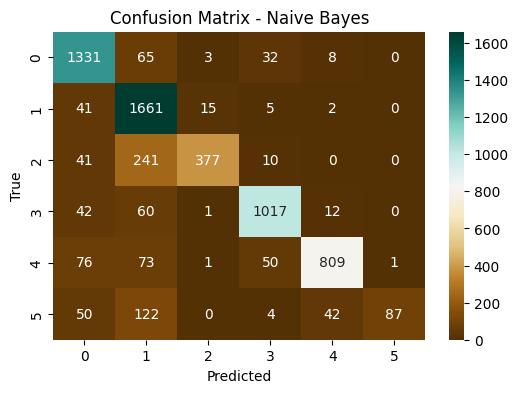

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_valid_pred_nb = nb_model.predict(X_valid_tfidf)
y_test_pred_nb = nb_model.predict(X_test_tfidf)

#Calculating Classification Matrix
valid_acc_nb = accuracy_score(y_valid, y_valid_pred_nb)
test_acc_nb = accuracy_score(y_test, y_test_pred_nb)

valid_prec_nb = precision_score(y_valid, y_valid_pred_nb, average='weighted')
test_prec_nb = precision_score(y_test, y_test_pred_nb, average='weighted')

valid_recall_nb = recall_score(y_valid, y_valid_pred_nb, average='weighted')
test_recall_nb = recall_score(y_test, y_test_pred_nb, average='weighted')

print(f"Naive Bayes Validation Accuracy {valid_acc_nb}")
print(f"Naive Bayes Test Accuracy {test_acc_nb}")
print(f"Naive Bayes Validation Precision {valid_prec_nb}")
print(f"Naive Bayes Test Precision {test_prec_nb}")
print(f"Naive Bayes Validation Recall {valid_recall_nb}")
print(f"Naive Bayes Test Recall {test_recall_nb}")

validation_classification_report_nb = classification_report(y_valid, y_valid_pred_tree, output_dict=True)
test_classification_report_nb = classification_report(y_test, y_test_pred_tree, output_dict=True)
print(f"{validation_classification_report_nb}")
print(f"{test_classification_report_nb}")

# Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_test_pred_nb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="BrBG")
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **KNN**

KNN Validation Accuracy 0.8057324840764332
KNN Test Accuracy 0.807931199235547
KNN Validation Precision 0.8070937256670244
KNN Test Precision 0.8087460477498177
KNN Validation Recall 0.8057324840764332
KNN Test Recall 0.807931199235547
{'0': {'precision': 0.8034188034188035, 'recall': 0.8545454545454545, 'f1-score': 0.8281938325991189, 'support': 220.0}, '1': {'precision': 0.7751004016064257, 'recall': 0.8177966101694916, 'f1-score': 0.7958762886597938, 'support': 236.0}, '2': {'precision': 0.7821782178217822, 'recall': 0.7821782178217822, 'f1-score': 0.7821782178217822, 'support': 101.0}, '3': {'precision': 0.8197674418604651, 'recall': 0.8057142857142857, 'f1-score': 0.8126801152737753, 'support': 175.0}, '4': {'precision': 0.8535031847133758, 'recall': 0.7976190476190477, 'f1-score': 0.8246153846153846, 'support': 168.0}, '5': {'precision': 0.8275862068965517, 'recall': 0.5714285714285714, 'f1-score': 0.676056338028169, 'support': 42.0}, 'accuracy': 0.8057324840764332, 'macro avg': 

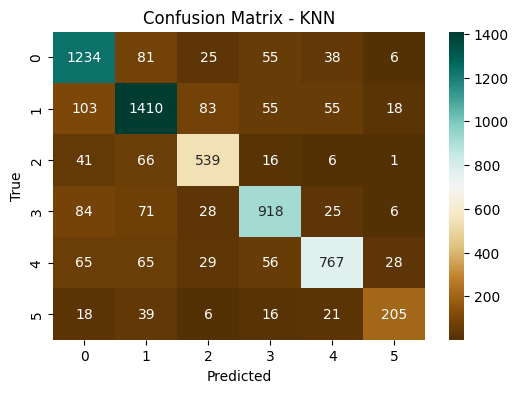

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors
knn_model.fit(X_train_tfidf, y_train)

# Predictions
y_valid_pred_knn = knn_model.predict(X_valid_tfidf)
y_test_pred_knn = knn_model.predict(X_test_tfidf)

#Calculating Classification Matrix
valid_acc_knn = accuracy_score(y_valid, y_valid_pred_knn)
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)

valid_prec_knn = precision_score(y_valid, y_valid_pred_knn, average='weighted')
test_prec_knn = precision_score(y_test, y_test_pred_knn, average='weighted')

valid_recall_knn = recall_score(y_valid, y_valid_pred_knn, average='weighted')
test_recall_knn = recall_score(y_test, y_test_pred_knn, average='weighted')

print(f"KNN Validation Accuracy {valid_acc_knn}")
print(f"KNN Test Accuracy {test_acc_knn}")
print(f"KNN Validation Precision {valid_prec_knn}")
print(f"KNN Test Precision {test_prec_knn}")
print(f"KNN Validation Recall {valid_recall_knn}")
print(f"KNN Test Recall {test_recall_knn}")

validation_classification_report_knn = classification_report(y_valid, y_valid_pred_knn, output_dict=True)
test_classification_report_knn = classification_report(y_test, y_test_pred_knn, output_dict=True)
print(f"{validation_classification_report_knn}")
print(f"{test_classification_report_knn}")

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, y_test_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="BrBG")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **Neural Network**

Neural Network Validation Accuracy 0.8970276008492569
Neural Network Test Accuracy 0.9117693900302596
Neural Network Validation Precision 0.8980389333157056
Neural Network Test Precision 0.9121540415108478
Neural Network Validation Recall 0.8970276008492569
Neural Network Test Recall 0.9117693900302596
{'0': {'precision': 0.9230769230769231, 'recall': 0.8727272727272727, 'f1-score': 0.897196261682243, 'support': 220.0}, '1': {'precision': 0.8942731277533039, 'recall': 0.8601694915254238, 'f1-score': 0.8768898488120951, 'support': 236.0}, '2': {'precision': 0.8363636363636363, 'recall': 0.9108910891089109, 'f1-score': 0.8720379146919431, 'support': 101.0}, '3': {'precision': 0.8882978723404256, 'recall': 0.9542857142857143, 'f1-score': 0.9201101928374655, 'support': 175.0}, '4': {'precision': 0.9166666666666666, 'recall': 0.9166666666666666, 'f1-score': 0.9166666666666666, 'support': 168.0}, '5': {'precision': 0.9024390243902439, 'recall': 0.8809523809523809, 'f1-score': 0.8915662650602

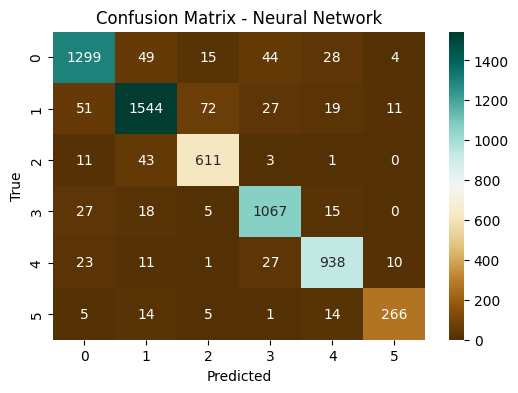

In [ ]:
nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)  # Adjust hyperparameters as needed
nn_model.fit(X_train_tfidf, y_train)

# Predictions
y_valid_pred_nn = nn_model.predict(X_valid_tfidf)
y_test_pred_nn = nn_model.predict(X_test_tfidf)

#Calculating Classification Matrix
valid_acc_nn = accuracy_score(y_valid, y_valid_pred_nn)
test_acc_nn = accuracy_score(y_test, y_test_pred_nn)

valid_prec_nn = precision_score(y_valid, y_valid_pred_nn, average='weighted')
test_prec_nn = precision_score(y_test, y_test_pred_nn, average='weighted')

valid_recall_nn = recall_score(y_valid, y_valid_pred_nn, average='weighted')
test_recall_nn = recall_score(y_test, y_test_pred_nn, average='weighted')

print(f"Neural Network Validation Accuracy {valid_acc_nn}")
print(f"Neural Network Test Accuracy {test_acc_nn}")
print(f"Neural Network Validation Precision {valid_prec_nn}")
print(f"Neural Network Test Precision {test_prec_nn}")
print(f"Neural Network Validation Recall {valid_recall_nn}")
print(f"Neural Network Test Recall {test_recall_nn}")

validation_classification_report_nn = classification_report(y_valid, y_valid_pred_nn, output_dict=True)
test_classification_report_nn = classification_report(y_test, y_test_pred_nn, output_dict=True)
print(f"{validation_classification_report_nn}")
print(f"{test_classification_report_nn}")

# Confusion Matrix for Neural Network
cm_nn = confusion_matrix(y_test, y_test_pred_nn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn, annot=True, fmt="d", cmap="BrBG")
plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

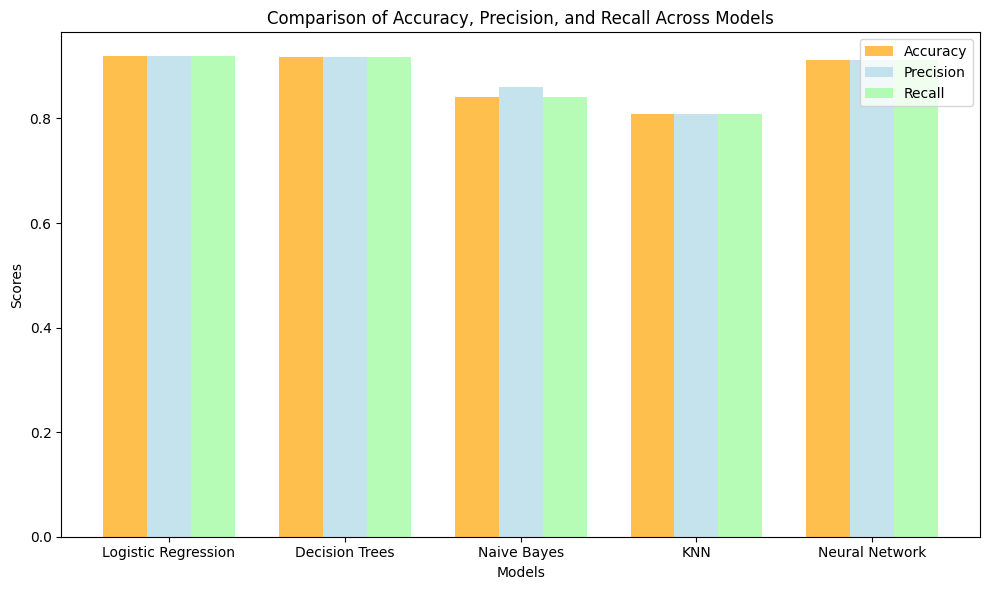

In [ ]:
accuracy = {"Logistic Regression": test_acc_log, "Decision Trees": test_acc_tree, "Naive Bayes": test_acc_nb, "KNN": test_acc_knn, "Neural Network": test_acc_nn}
precisions = {"Logistic Regression": test_prec_log, "Decision Trees": test_prec_tree, "Naive Bayes": test_prec_nb, "KNN": test_prec_knn, "Neural Network": test_prec_nn}
recalls = {"Logistic Regression": test_recall_log, "Decision Trees": test_recall_tree, "Naive Bayes": test_recall_nb, "KNN": test_recall_knn, "Neural Network": test_recall_nn}

models = list(precisions.keys())
accuracy_values = list(accuracy.values())
precision_values = list(precisions.values())
recall_values = list(recalls.values())

# Create x-axis positions
x = np.arange(len(models))  # The label locations
width = 0.25  # Width of each bar

# Plot the bars with correct offsets
plt.figure(figsize=(10, 6))
plt.bar(x - width, accuracy_values, width, label='Accuracy', color='orange', alpha=0.7)
plt.bar(x, precision_values, width, label='Precision', color='lightblue', alpha=0.7)
plt.bar(x + width, recall_values, width, label='Recall', color='palegreen', alpha=0.7)

# Add labels, title, and legend
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Comparison of Accuracy, Precision, and Recall Across Models')
plt.xticks(x, models)  # Place x-ticks at the correct positions
plt.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

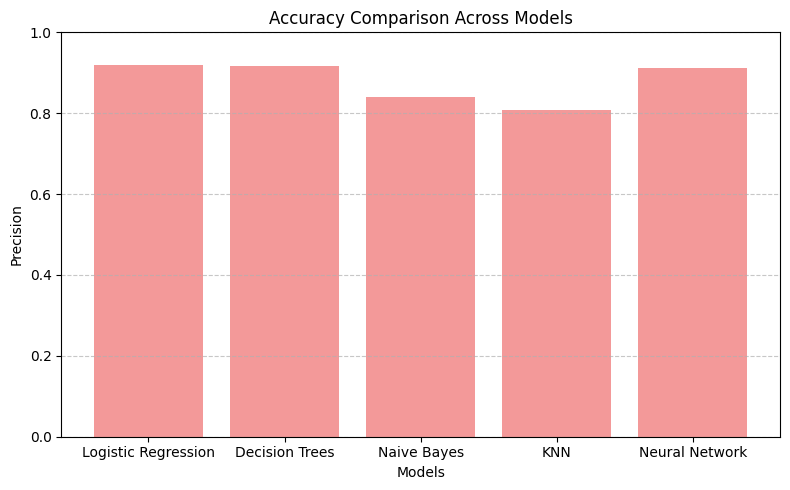

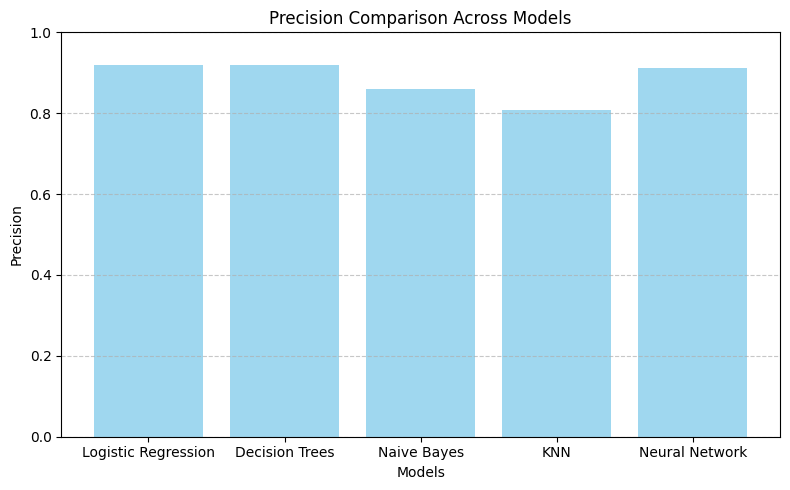

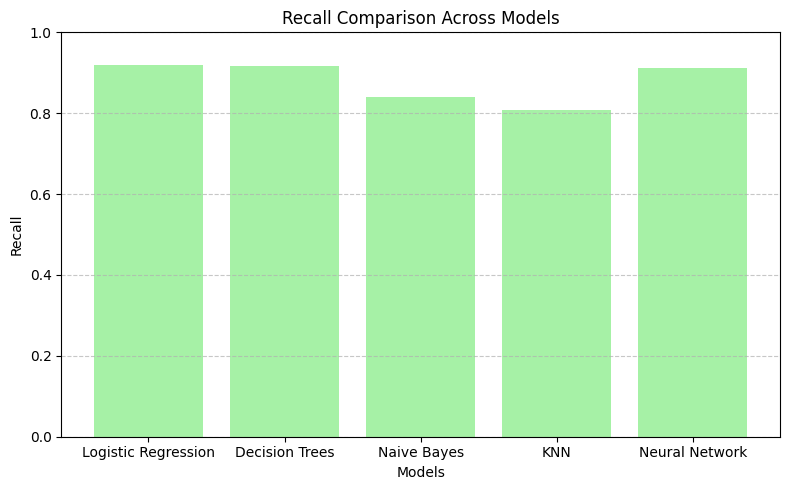

In [ ]:
# Accuracy comparison bar chart
plt.figure(figsize=(8, 5))
plt.bar(models, accuracy_values, color='lightcoral', alpha=0.8)
plt.xlabel('Models')
plt.ylabel('Precision')
plt.title('Accuracy Comparison Across Models')
plt.ylim(0, 1)  # Ensure the y-axis is scaled to [0, 1]
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Precision comparison bar chart
plt.figure(figsize=(8, 5))
plt.bar(models, precision_values, color='skyblue', alpha=0.8)
plt.xlabel('Models')
plt.ylabel('Precision')
plt.title('Precision Comparison Across Models')
plt.ylim(0, 1)  # Ensure the y-axis is scaled to [0, 1]
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Recall comparison bar chart
plt.figure(figsize=(8, 5))
plt.bar(models, recall_values, color='lightgreen', alpha=0.8)
plt.xlabel('Models')
plt.ylabel('Recall')
plt.title('Recall Comparison Across Models')
plt.ylim(0, 1)  # Ensure the y-axis is scaled to [0, 1]
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()